In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

cpu_df = pd.read_csv(
    "../data/Processed/cpu_features_new.csv"
)

cpu_df["ts"] = pd.to_datetime(
    cpu_df["ts"],
    format="mixed",
    utc=True
)

cpu_df["timestamp_display"] = (
    cpu_df["ts"]
    .dt.strftime("%d-%m-%Y %H:%M")
)
cpu_df["timestamp_display"].head()

0    11-06-2026 00:56
1    11-06-2026 01:01
2    11-06-2026 01:06
3    11-06-2026 01:11
4    11-06-2026 01:16
Name: timestamp_display, dtype: object

In [2]:
# Extract behaviour features
cpu_df["hour_of_day"] = (
    cpu_df["ts"].dt.hour
)

cpu_df["day_of_week"] = (
    cpu_df["ts"].dt.dayofweek
)
# Weekend flag
cpu_df["is_weekend"] = (
    cpu_df["day_of_week"] >= 5
).astype(int)

cpu_df[
    [
        "ts",
        "hour_of_day",
        "day_of_week",
        "is_weekend"
    ]
].head()

,ts,hour_of_day,day_of_week,is_weekend
0,2026-06-11 00:56:36.480000+00:00,0,3,0
1,2026-06-11 01:01:37.651000+00:00,1,3,0
2,2026-06-11 01:06:36.451000+00:00,1,3,0
3,2026-06-11 01:11:38.391000+00:00,1,3,0
4,2026-06-11 01:16:36.755000+00:00,1,3,0


In [3]:
# Save updated dataset
cpu_df.to_csv(
    "../data/Processed/cpu_baseline_new.csv",
    index=False
)

In [4]:
# Average CPU By Hour
# This tells us:
# Business Hours
# Peak CPU Hours
# Off-Peak Hours

hourly_cpu = (
    cpu_df
    .groupby("hour_of_day")
    ["cpu_usage_pct"]
    .mean()
    .reset_index()
)
hourly_cpu

,hour_of_day,cpu_usage_pct
0,0,10.987373
1,1,11.188160
2,2,11.233472
3,3,11.284583
4,4,11.581146
5,5,12.111285
6,6,11.990590
7,7,12.054201
8,8,12.074653
9,9,11.929127


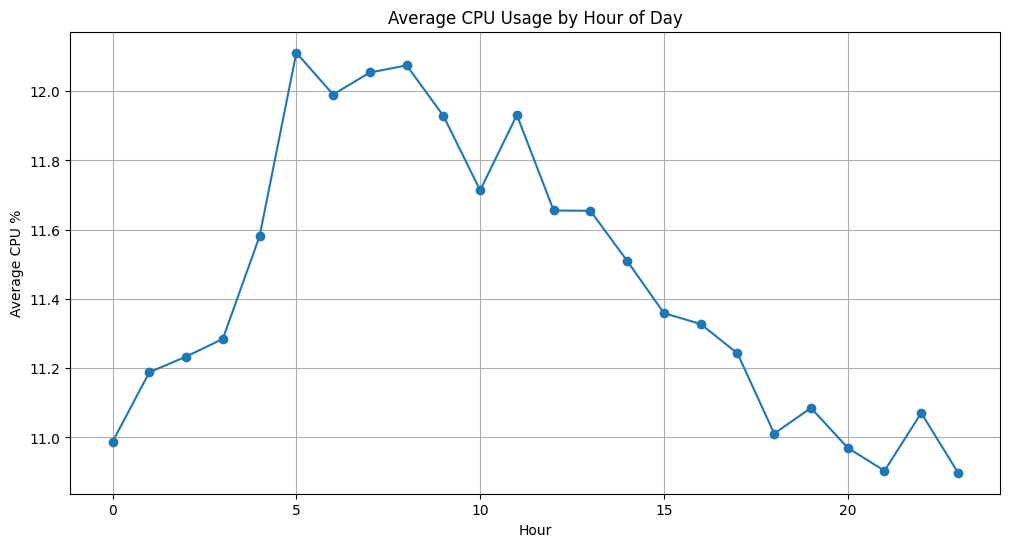

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    hourly_cpu["hour_of_day"],
    hourly_cpu["cpu_usage_pct"],
    marker="o"
)

plt.title(
    "Average CPU Usage by Hour of Day"
)

plt.xlabel("Hour")

plt.ylabel("Average CPU %")

plt.grid(True)

plt.show()

In [6]:
# Average CPU by weekday
days = {

    0:"Mon",
    1:"Tue",
    2:"Wed",
    3:"Thu",
    4:"Fri",
    5:"Sat",
    6:"Sun"
}

weekday_cpu = (
    cpu_df
    .groupby("day_of_week")
    ["cpu_usage_pct"]
    .mean()
    .reset_index()
)

weekday_cpu["day"] = (
    weekday_cpu["day_of_week"]
    .map(days)
)

weekday_cpu

,day_of_week,cpu_usage_pct,day
0,0,11.327593,Mon
1,1,11.502523,Tue
2,2,11.817697,Wed
3,3,11.655905,Thu
4,4,11.401655,Fri
5,5,11.282674,Sat
6,6,11.161620,Sun


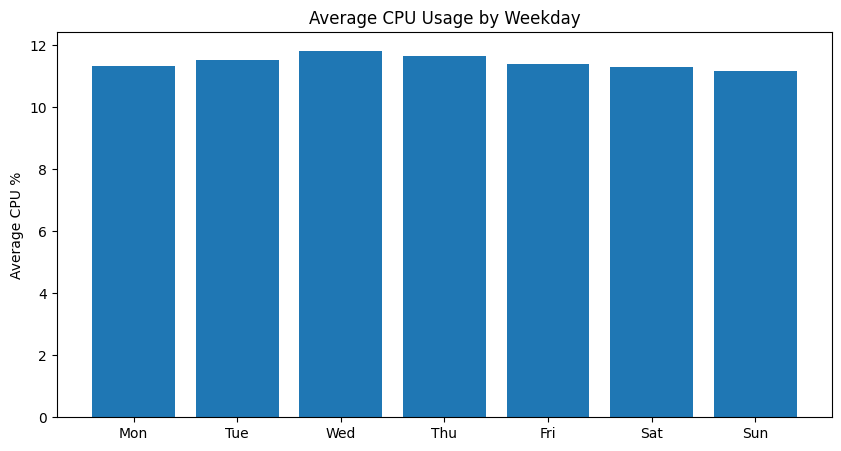

In [7]:
plt.figure(figsize=(10,5))

plt.bar(
    weekday_cpu["day"],
    weekday_cpu["cpu_usage_pct"]
)

plt.title(
    "Average CPU Usage by Weekday"
)

plt.ylabel("Average CPU %")

plt.show()

In [8]:
# Average CPU by server
server_cpu = (
    cpu_df
    .groupby("hostName")
    ["cpu_usage_pct"]
    .mean()
    .reset_index()
)
server_cpu

,hostName,cpu_usage_pct
0,10.10.10.150,2.376422
1,10.10.10.2,28.188230
2,10.10.10.65,3.813568


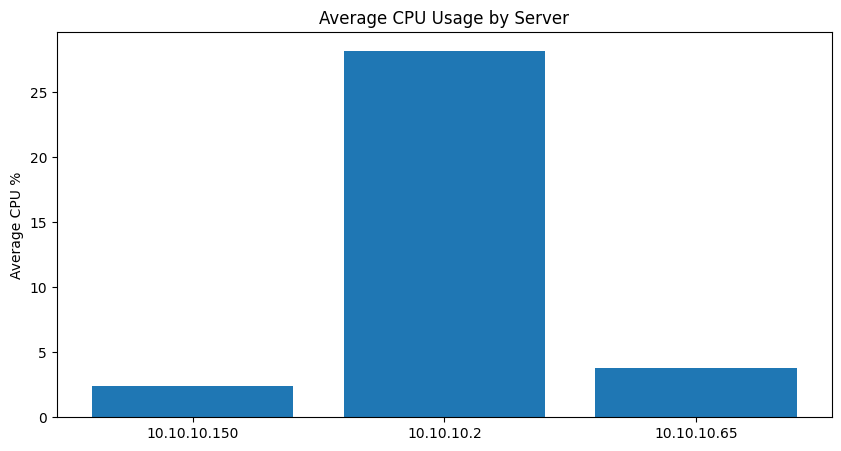

In [9]:
plt.figure(figsize=(10,5))

plt.bar(
    server_cpu["hostName"],
    server_cpu["cpu_usage_pct"]
)

plt.title(
    "Average CPU Usage by Server"
)

plt.ylabel("Average CPU %")

plt.show()

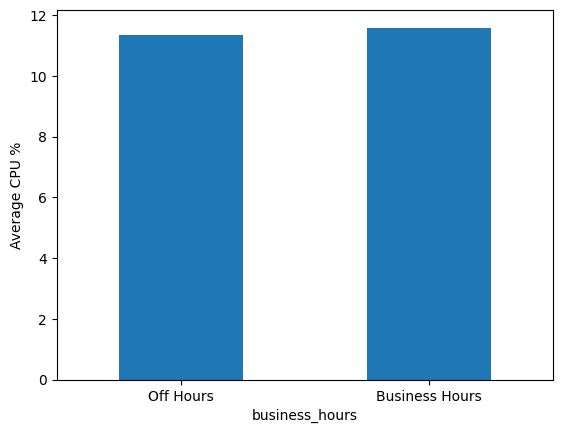

In [10]:
# Business hours vs Off hours
cpu_df["business_hours"] = (
    cpu_df["hour_of_day"]
    .between(8,18)
).astype(int)

cpu_df.groupby(
    "business_hours"
)["cpu_usage_pct"].mean()

business_cpu = (
    cpu_df
    .groupby("business_hours")
    ["cpu_usage_pct"]
    .mean()
)

business_cpu.plot(
    kind="bar"
)

plt.xticks(
    [0,1],
    ["Off Hours","Business Hours"],
    rotation=0
)

plt.ylabel(
    "Average CPU %"
)

plt.show()

In [11]:
# Peak CPU Period detection
hourly_cpu.sort_values(
    "cpu_usage_pct",
    ascending=False
).head(5)

,hour_of_day,cpu_usage_pct
5,5,12.111285
8,8,12.074653
7,7,12.054201
6,6,11.990590
11,11,11.931151
